In order to run the bellow cells, download Amazon datasets for electronics from https://amazon-reviews-2023.aithub.io/main.html and place them in the /data folder.

In [1]:
import json 
import pandas as pd 

In [2]:
with open('../../data/meta_Electronics.jsonl', 'r') as f:
    first_line = json.loads(f.readline())

In [3]:
first_line

{'main_category': 'All Electronics',
 'title': 'FS-1051 FATSHARK TELEPORTER V3 HEADSET',
 'average_rating': 3.5,
 'rating_number': 6,
 'features': [],
 'description': ['Teleporter V3 The “Teleporter V3” kit sets a new level of value in the FPV world with Fat Shark renowned performance and quality. The fun of FPV is experienced firsthand through the large screen FPV headset with integrated NexwaveRF receiver technology while simultaneously recording onboard HD footage with the included “PilotHD” camera. The “Teleporter V3” kit comes complete with everything you need to step into the cockpit of your FPV vehicle. We’ve included our powerful 250mW 5.8Ghz transmitter, 25 degree FOV headset (largest QVGA display available), the brand new “PilotHD” camera with live AV out and all the cables, antennas and connectors needed.'],
 'price': None,
 'images': [{'thumb': 'https://m.media-amazon.com/images/I/41qrX56lsYL._AC_US40_.jpg',
   'large': 'https://m.media-amazon.com/images/I/41qrX56lsYL._AC_.

## Filter Items that have been observed for the first time in year 2022 or later.

In [4]:
def filter_data(data: dict) -> dict:
    filter = False
    if int(data['details']['Date First Available'][-4:]) < 2022:
        filter = True

    return filter

In [6]:
import json

with open("../../data/meta_Electronics.jsonl", 'r') as fp:
    with open("../../data/meta_Electronics_2022_2023.jsonl", 'a', encoding='utf-8') as fp_out:
        with open("../../data/meta_Electronics_2022_2023_no_date.jsonl", 'a', encoding='utf-8') as fp_out_no_date:
            i = 0
            for line in fp:
                try:
                    # Parse the json inside the try block to catch corrupt lines
                    data = json.loads(line.strip())
                    filter = filter_data(data)
                    if not filter:
                        json.dump(data, fp_out)
                        fp_out.write('\n')
                        fp_out.flush()
                except json.JSONDecodeError:
                    # Skip corrupt JSON lines completely
                    pass
                except Exception:
                    # If it parses but has missing/bad dates, dump it here
                    try:
                        json.dump(data, fp_out_no_date)
                        fp_out_no_date.write('\n')
                        fp_out_no_date.flush()
                    except:
                        pass
                
                i += 1
                if i % 10000 == 0:
                    print(f"Processed {i} lines")

Processed 10000 lines
Processed 20000 lines
Processed 30000 lines
Processed 40000 lines
Processed 50000 lines
Processed 60000 lines
Processed 70000 lines
Processed 80000 lines
Processed 90000 lines
Processed 100000 lines
Processed 110000 lines
Processed 120000 lines
Processed 130000 lines
Processed 140000 lines
Processed 150000 lines
Processed 160000 lines
Processed 170000 lines
Processed 180000 lines
Processed 190000 lines
Processed 200000 lines
Processed 210000 lines
Processed 220000 lines
Processed 230000 lines
Processed 240000 lines
Processed 250000 lines
Processed 260000 lines


## Split the items into two categories: "has main category", "does not have main category"

In [7]:
def filter_category(data: dict) -> dict:
    filter = False
    if data['main_category'] == None:
        filter = True

    return filter   

In [8]:
import json

with open("../../data/meta_Electronics_2022_2023.jsonl", 'r') as fp:
    with open("../../data/meta_Electronics_2022_2023_with_category.jsonl", 'a', encoding='utf-8') as fp_out:
        with open("../../data/meta_Electronics_2022_2023_no_category.jsonl", 'a', encoding='utf-8') as fp_out_no_category:
            for line in fp:
                data = json.loads(line.strip())

                if not filter_category(data):
                    json.dump(data, fp_out)
                    fp_out.write('\n')
                    fp_out.flush()
                else:
                    json.dump(data, fp_out_no_category)
                    fp_out_no_category.write('\n')
                    fp_out_no_category.flush()

## Explore distribution by categories

In [9]:
df = pd.read_json('../../data/meta_Electronics_2022_2023_with_category.jsonl', lines=True)

In [10]:
df.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Amazon Home,"Outer Space Planets Stickers(50Pcs),Planetary ...",4.5,50,[PROFESSIONAL STICKER SHOP.There are 50 differ...,"[Features:, - Clear picture and exquisite prin...",3.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Watch Before Buying! Huge Waterpro...,Affoto,"[Electronics, Computers & Accessories, Laptop ...","{'Brand': 'Affoto', 'Color': 'Outer Space', 'S...",B0BPLX8B2K,NaN
1,Computers,"Gateway 15.6"" FHD Ultra Slim Budget Notebook, ...",4.1,15,"[【Processor】4 Core, 4 Threads, 4MB Cache, up t...","[Processor:, Intel® Pentium® Silver N5030 Proc...",189.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'Watch before you order ', 'url': '...",Gateway,"[Electronics, Computers & Accessories, Compute...",{'Standing screen display size': '15.6 Inches'...,B0BYBG1PPD,NaN
2,Cell Phones & Accessories,May Chen Compatible with MacBook Pro 16 inch C...,4.5,649,[【 COMPATIBLE WITH 】 Designed to Fits Perfectl...,[May Chen High Quality Plastic Hard Shell Case...,26.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'MOSISO Plastic Hard Shell Compati...,May Chen,"[Electronics, Computers & Accessories, Laptop ...","{'Standing screen display size': '16 Inches', ...",B0822SL7JX,NaN
3,All Electronics,"LENTION USB C Docking Station, 10 Gbps USB C&U...",4.4,16,[10-in-1 Docking Station - CB-D65 laptop docki...,[],89.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'LENTION D65 Upgrade Docking Statio...,LENTION,"[Electronics, Computers & Accessories, Laptop ...",{'Package Dimensions': '9.17 x 4.33 x 1.54 inc...,B0BKS1K986,NaN
4,All Electronics,1X (No Bluetooth) Eaglewireless Replacement To...,3.0,4,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Eaglewireless,[],{'Package Dimensions': '5.2 x 2.13 x 0.91 inch...,B09MY246CC,NaN


<Axes: xlabel='main_category'>

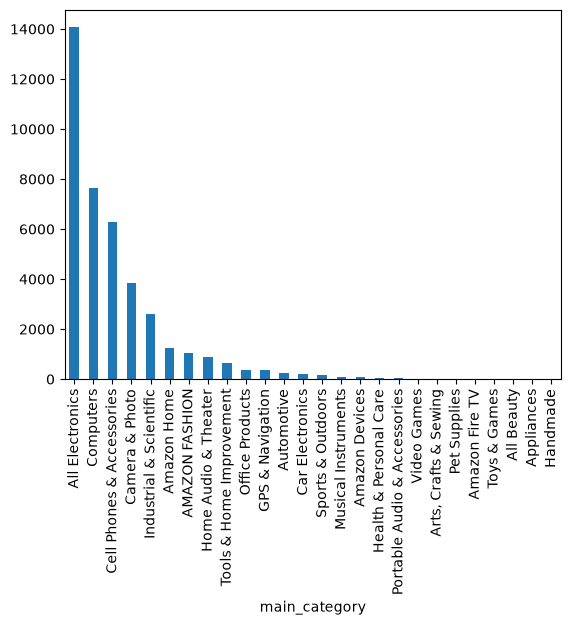

In [11]:
df['main_category'].value_counts().plot(kind='bar')

## Filter out items that have at least 100 ratings


In [12]:
df_ratings_100 = df[df['rating_number'] >= 100]

In [13]:
len(df)

39910

In [14]:
len(df_ratings_100)

10654

## Explore distribution of ratings

<Axes: title={'center': 'Distribution of Average Ratings for Products with at least 100 Ratings'}, ylabel='Frequency'>

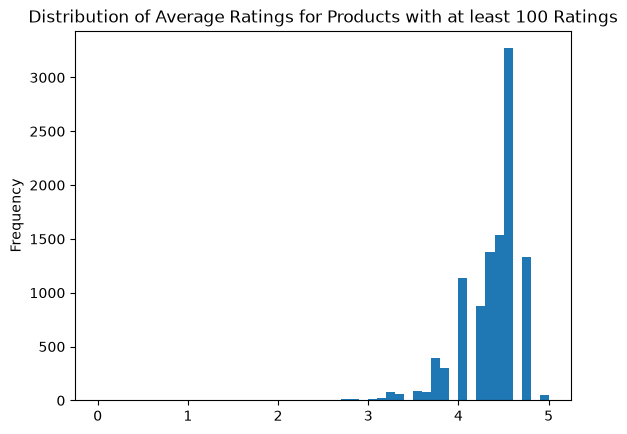

In [15]:
df_ratings_100['average_rating'].plot(kind='hist', bins=50,range=(0,5), title='Distribution of Average Ratings for Products with at least 100 Ratings')

### sample 1k items

In [16]:
df_sample_1000 = df_ratings_100.sample(n=1000, random_state=20)

<Axes: title={'center': 'Distribution of Prices for Sample of Products with at least 100 Ratings'}, ylabel='Frequency'>

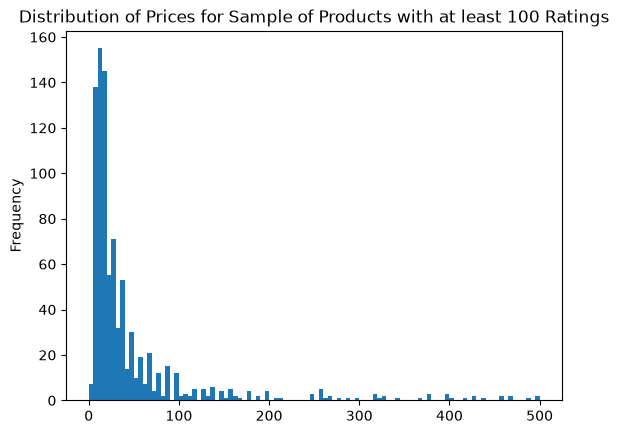

In [17]:
df_sample_1000['price'].plot(kind='hist', bins=100, range=(0,500), title='Distribution of Prices for Sample of Products with at least 100 Ratings')

<Axes: xlabel='main_category'>

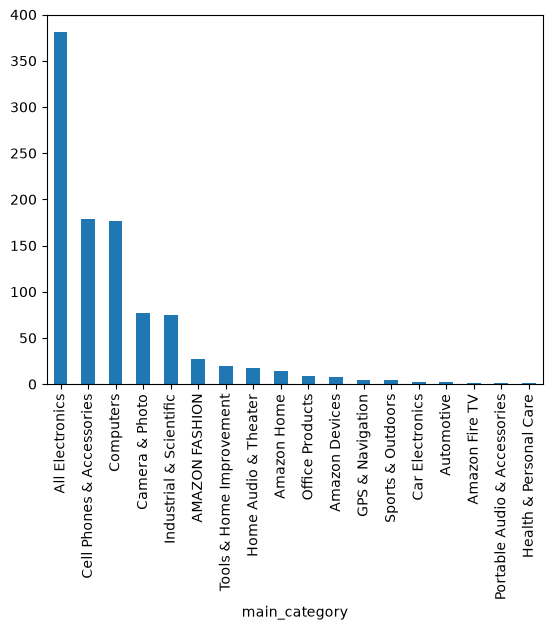

In [18]:
df_sample_1000['main_category'].value_counts().plot(kind='bar')

## Convert all districute rating into JSON

In [19]:
df_ratings_100.to_json('../../data/meta_Electronics_2022_2023_with_category_ratings_100.jsonl', orient='records', lines=True)

In [20]:
df_sample_1000.to_json('../../data/meta_Electronics_2022_2023_with_category_ratings_100_sample_1000.jsonl', orient='records', lines=True)

## Extract ratings that match sampled data

In [21]:
df_ratings_100 = pd.read_json('../../data/meta_Electronics_2022_2023_with_category_ratings_100.jsonl', lines=True)
df_sample_1000 = pd.read_json('../../data/meta_Electronics_2022_2023_with_category_ratings_100_sample_1000.jsonl', lines=True)

In [23]:
from typing import Any
import json

with open("../../data/Electronics.jsonl", 'r') as fp:
    with open("../../data/Electronics_2022_2023_with_category_ratings_100.jsonl", 'a') as fp_out:
        id_list = set[Any](df_ratings_100['parent_asin'].values)
        i = 0

        for line in fp:
            try:
                # Catch the corrupt JSON line
                data = json.loads(line.strip())

                if data['parent_asin'] in id_list:
                    json.dump(data, fp_out)
                    fp_out.write('\n')
                    fp_out.flush()
            except json.JSONDecodeError:
                # Silently skip the broken line and move to the next one
                pass

            i += 1
            if i % 100000 == 0:
                print(f"Processed {i} lines")

Processed 100000 lines
Processed 200000 lines
Processed 300000 lines
Processed 400000 lines
Processed 500000 lines
Processed 600000 lines
Processed 700000 lines
Processed 800000 lines
Processed 900000 lines
Processed 1000000 lines
Processed 1100000 lines
Processed 1200000 lines
Processed 1300000 lines
Processed 1400000 lines
Processed 1500000 lines
Processed 1600000 lines
Processed 1700000 lines
Processed 1800000 lines
Processed 1900000 lines
Processed 2000000 lines


In [24]:
import json

with open("../../data/Electronics_2022_2023_with_category_ratings_100.jsonl", 'r') as fp:
    with open("../../data/Electronics_2022_2023_with_category_ratings_100_sample_1000.jsonl", 'a') as fp_out:
        id_list = set(df_sample_1000['parent_asin'].values)
        i = 0

        for line in fp:
            data = json.loads(line.strip())

            if data['parent_asin'] in id_list:
                json.dump(data, fp_out)
                fp_out.write('\n')
                fp_out.flush()

            i += 1
            if i % 100000 == 0:
                print(f"Processed {i} lines")